
# Masterclass Notebook: Interpretabilidad vs Explicabilidad de Modelos
**Caso de estudio:** Titanic Survival Prediction  
**Autor:** Josef Rodriguez  
**Objetivo:** comparar un modelo interpretable con modelos tipo *black box* y aplicar métodos modernos de explicación.

---

## Estructura de la clase

1. Problema Titanic  
2. Logistic Regression → modelo interpretable  
3. Random Forest → modelo black box  
4. XGBoost / LightGBM / CatBoost → modelos boosting  
5. Feature Importance  
6. Permutation Importance  
7. Partial Dependence / ICE  
8. SHAP global  
9. SHAP individual  
10. Conclusiones industriales

---

## Pregunta de negocio

> Queremos predecir si una persona sobrevivió o no al Titanic a partir de variables observables como sexo, edad, clase, tarifa, puerto de embarque y estructura familiar.

Este problema es ideal porque:
- Fácil de entender 
- Tiene variables muy interpretables,
- Permite comparar **modelos simples** vs **modelos complejos**,
- Funciona muy bien con técnicas de explicabilidad modernas.



## 1. Diferencia conceptual

### Interpretabilidad
Un modelo es **interpretable** cuando podemos entender directamente cómo toma decisiones.

Ejemplos:
- Regresión lineal
- Regresión logística
- Árboles pequeños
- Modelos scorecard / WoE

### Explicabilidad
La **explicabilidad** aparece cuando el modelo no es transparente por sí mismo, pero usamos herramientas externas para entenderlo.

Ejemplos:
- SHAP
- Permutation Importance
- Partial Dependence Plots (PDP)
- ICE plots
- LIME

### Idea clave de la clase
- **Logistic Regression** representa la parte interpretable.
- **Random Forest / XGBoost / LightGBM / CatBoost** representan modelos de mayor complejidad.
- Luego usamos métodos de explicación para abrir la “caja negra”.


In [1]:

# =============================
# 1. Imports
# =============================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Opcionales
HAS_XGB = True
HAS_LGBM = True
HAS_CAT = True
HAS_SHAP = True

try:
    from xgboost import XGBClassifier
except Exception:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier
except Exception:
    HAS_LGBM = False

try:
    from catboost import CatBoostClassifier
except Exception:
    HAS_CAT = False

try:
    import shap
except Exception:
    HAS_SHAP = False

print("XGBoost disponible:", HAS_XGB)
print("LightGBM disponible:", HAS_LGBM)
print("CatBoost disponible:", HAS_CAT)
print("SHAP disponible:", HAS_SHAP)


XGBoost disponible: True
LightGBM disponible: True
CatBoost disponible: True
SHAP disponible: True


In [2]:

# =============================
# 2. Carga robusta del dataset Titanic
# =============================

def load_titanic():
    """
    Carga el dataset Titanic desde el repositorio del curso.
    Si falla, intenta cargar desde seaborn y luego desde OpenML.
    Devuelve un DataFrame estandarizado.
    """

    url_repo = "https://raw.githubusercontent.com/josefrodrim/ML-course/main/data/Titanic-Dataset.csv"

    try:
        df = pd.read_csv(url_repo)
        source = "github_repo"

    except Exception:

        try:
            import seaborn as sns
            df = sns.load_dataset("titanic")
            source = "seaborn"

        except Exception:

            from sklearn.datasets import fetch_openml

            titanic = fetch_openml(name="titanic", version=1, as_frame=True)
            df = titanic.frame.copy()
            source = "openml"

    # =============================
    # Estandarización de columnas
    # =============================

    rename_map = {
        "PassengerId": "passenger_id",
        "Survived": "survived",
        "Pclass": "pclass",
        "Name": "name",
        "Sex": "sex",
        "Age": "age",
        "SibSp": "sibsp",
        "Parch": "parch",
        "Ticket": "ticket",
        "Fare": "fare",
        "Cabin": "cabin",
        "Embarked": "embarked",
    }

    # Renombrar solo si existen
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

    # Seleccionar columnas relevantes
    keep_cols = [
        "survived",
        "pclass",
        "sex",
        "age",
        "sibsp",
        "parch",
        "fare",
        "embarked",
    ]

    existing = [c for c in keep_cols if c in df.columns]
    df = df[existing].copy()

    # Convertir target si viene como string
    if df["survived"].dtype == "object":
        df["survived"] = df["survived"].astype(int)

    return df, source


df, source = load_titanic()

print("Fuente:", source)
print("Shape:", df.shape)

df.head()

Fuente: github_repo
Shape: (891, 8)


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S



## 2.1 Variables del problema

- **survived**: variable objetivo (1 = sobrevivió, 0 = no sobrevivió)
- **pclass**: clase del ticket
- **sex**: sexo
- **age**: edad
- **sibsp**: número de hermanos/cónyuges a bordo
- **parch**: número de padres/hijos a bordo
- **fare**: tarifa pagada
- **embarked**: puerto de embarque

Además, aprovecharemos otras variables derivadas o descriptivas si están disponibles.


In [3]:

# =============================
# 3. Revisión rápida del dataset
# =============================
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


In [4]:

df.isnull().mean().sort_values(ascending=False)


age         0.198653
embarked    0.002245
survived    0.000000
pclass      0.000000
sex         0.000000
sibsp       0.000000
parch       0.000000
fare        0.000000
dtype: float64

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


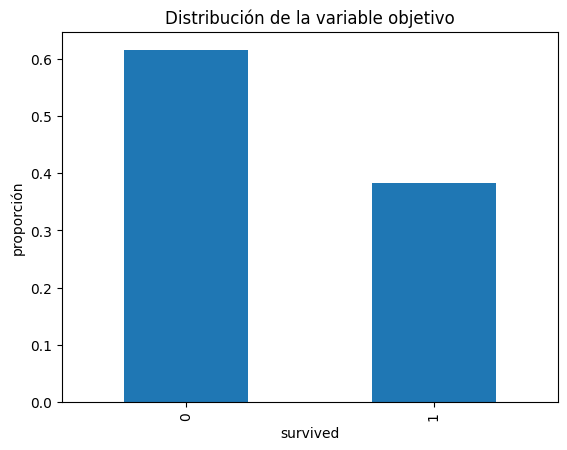

In [5]:

# Distribución del target
target_dist = df["survived"].value_counts(normalize=True).sort_index()
print(target_dist)

ax = target_dist.plot(kind="bar")
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("survived")
ax.set_ylabel("proporción")
plt.show()


In [6]:

# Relación simple y muy intuitiva: supervivencia por sexo
survival_by_sex = df.groupby("sex")["survived"].mean().sort_values(ascending=False)
survival_by_sex


sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

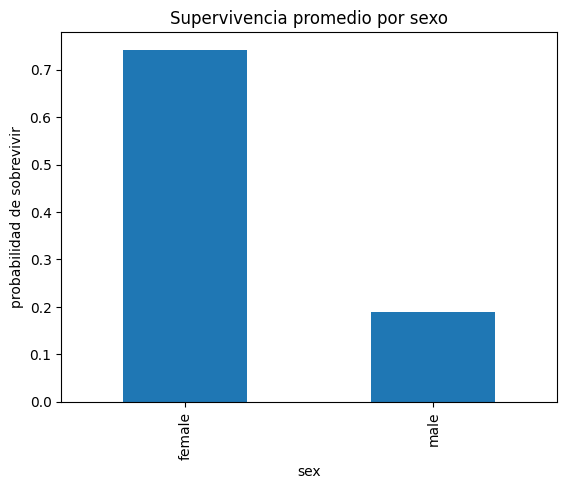

In [7]:

ax = survival_by_sex.plot(kind="bar")
ax.set_title("Supervivencia promedio por sexo")
ax.set_ylabel("probabilidad de sobrevivir")
plt.show()


In [8]:

# Relación con clase
survival_by_class = df.groupby("pclass")["survived"].mean().sort_index()
survival_by_class


pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

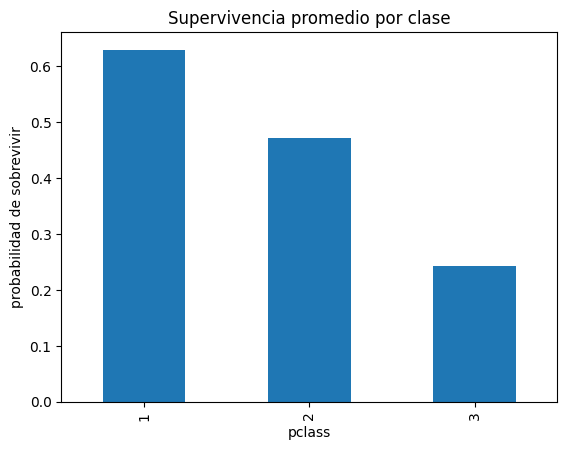

In [9]:

ax = survival_by_class.plot(kind="bar")
ax.set_title("Supervivencia promedio por clase")
ax.set_ylabel("probabilidad de sobrevivir")
plt.show()



## 3.1 Lectura de negocio preliminar

Antes de modelar ya vemos señales útiles:
- las mujeres tienden a sobrevivir más,
- los pasajeros de clase alta tendieron a sobrevivir más,
- la edad y la estructura familiar probablemente influyen.

Esto es muy valioso  porque luego podremos comprobar si los modelos capturan estos patrones.


In [10]:

# =============================
# 4. Feature engineering ligero
# =============================
work_df = df.copy()

work_df["family_size"] = work_df["sibsp"].fillna(0) + work_df["parch"].fillna(0) + 1
work_df["is_alone_flag"] = (work_df["family_size"] == 1).astype(int)
work_df["fare_per_person"] = work_df["fare"] / work_df["family_size"].replace(0, 1)

# Variables finales
target = "survived"
features = [c for c in work_df.columns if c != target]

work_df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,family_size,is_alone_flag,fare_per_person
0,0,3,male,22.0,1,0,7.2500,S,2,0,3.62500
1,1,1,female,38.0,1,0,71.2833,C,2,0,35.64165
2,1,3,female,26.0,0,0,7.9250,S,1,1,7.92500
3,1,1,female,35.0,1,0,53.1000,S,2,0,26.55000
4,0,3,male,35.0,0,0,8.0500,S,1,1,8.05000



## 4.1 Comentario didáctico

Aquí agregamos algunas variables sencillas:
- **family_size**  tamaño de la familia
- **is_alone_flag** flag si está solo 
- **fare_per_person** precio por familia

Este paso es importante porque muestra que incluso en una clase de explicabilidad, el *feature engineering* sigue siendo parte fundamental del trabajo del Data Scientist.


In [11]:

# =============================
# 5. Train / test split
# =============================
X = work_df[features].copy()
y = work_df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (668, 10) (668,)
Test : (223, 10) (223,)


In [12]:

# =============================
# 6. Preprocesamiento
# =============================
numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

print("Numéricas:", numeric_features)
print("Categóricas:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


Numéricas: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone_flag', 'fare_per_person']
Categóricas: ['sex', 'embarked']



## 5. Modelos a comparar

### Modelo interpretable
- **Logistic Regression**

### Modelos black-box / semi black-box
- **Random Forest**
- **XGBoost**
- **LightGBM**
- **CatBoost**

La idea no es solo comparar métricas, sino ver qué herramientas necesitamos para explicar cada familia de modelos.


In [13]:

# =============================
# 7. Definición de modelos
# =============================
models = {}

models["LogisticRegression"] = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

models["RandomForest"] = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42
    ))
])

if HAS_XGB:
    models["XGBoost"] = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=42
        ))
    ])

if HAS_LGBM:
    models["LightGBM"] = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            verbose=-1
        ))
    ])

if HAS_CAT:
    models["CatBoost"] = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", CatBoostClassifier(
            iterations=300,
            depth=5,
            learning_rate=0.05,
            verbose=False,
            random_state=42
        ))
    ])

list(models.keys())


['LogisticRegression', 'RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']

In [14]:

# =============================
# 8. Entrenamiento y evaluación
# =============================
results = []
fitted_models = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

    proba_train = pipe.predict_proba(X_train)[:, 1]
    proba_test = pipe.predict_proba(X_test)[:, 1]
    pred_test = (proba_test >= 0.5).astype(int)

    results.append({
        "model": name,
        "train_auc": roc_auc_score(y_train, proba_train),
        "test_auc": roc_auc_score(y_test, proba_test),
        "test_accuracy": accuracy_score(y_test, pred_test)
    })

results_df = pd.DataFrame(results).sort_values("test_auc", ascending=False).reset_index(drop=True)
results_df


,model,train_auc,test_auc,test_accuracy
0,CatBoost,0.976946,0.851171,0.798206
1,LogisticRegression,0.862134,0.846758,0.784753
2,RandomForest,0.926179,0.841920,0.798206
3,XGBoost,0.982014,0.791122,0.784753
4,LightGBM,0.996952,0.783653,0.784753


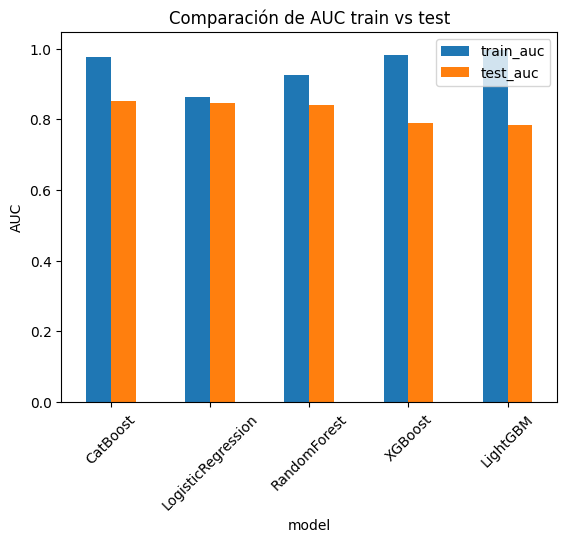

In [15]:

# Visualización de métricas
ax = results_df.set_index("model")[["train_auc", "test_auc"]].plot(kind="bar")
ax.set_title("Comparación de AUC train vs test")
ax.set_ylabel("AUC")
plt.xticks(rotation=45)
plt.show()



## 6. Primera lectura analítica

Con esta tabla puedes discutir:
- si hay diferencias materiales entre modelos,
- si hay señales de sobreajuste,
- si el modelo más complejo realmente mejora,
- cuánto sacrificamos en interpretabilidad al pasar de una logística a un boosting.

aquí vale mucho la pena preguntar:

> ¿Vale la pena usar un modelo más complejo si la mejora predictiva es marginal?


In [16]:

# Elegimos el mejor modelo por test_auc para la parte de explicabilidad avanzada
best_model_name = results_df.loc[0, "model"]
best_pipe = fitted_models[best_model_name]

print("Mejor modelo según test_auc:", best_model_name)


Mejor modelo según test_auc: CatBoost



# 7. Interpretabilidad directa: Logistic Regression

La regresión logística es un ejemplo clásico de **modelo interpretable**, porque sus coeficientes tienen una lectura relativamente directa sobre los *log-odds* de la probabilidad objetivo.

---

## Fórmula del modelo logístico

$$
\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x_1 + \cdots + \beta_k x_k
$$

donde:

- $p$ es la probabilidad de sobrevivir
- $\beta_0$ es el intercepto
- $\beta_j$ es el coeficiente asociado a la variable $x_j$

---

## Interpretación de los coeficientes

- Si $ \beta_j > 0 $, la variable **incrementa** la probabilidad de sobrevivir.
- Si $ \beta_j < 0 $, la variable **reduce** la probabilidad de sobrevivir.
- Si $ \beta_j = 0 $, la variable **no tiene efecto** en la predicción.

---

## Odds Ratio

Si exponenciamos el coeficiente:

$$
\text{Odds Ratio} = e^{\beta_j}
$$

obtenemos el **factor multiplicativo sobre los odds**.

### Interpretación

- $e^{\beta_j} > 1$ → aumenta la probabilidad relativa
- $e^{\beta_j} < 1$ → disminuye la probabilidad relativa
- $e^{\beta_j} = 1$ → no tiene efecto

---

## Ejemplo

Si

$$
\beta_{sex\_female} = 1.5
$$

entonces

$$
e^{1.5} \approx 4.48
$$

Interpretación:

> Las mujeres tendrían aproximadamente **4.5 veces mayores odds de sobrevivir** que los hombres, manteniendo constantes las demás variables.

In [17]:

# =============================
# 9. Coeficientes de la logística
# =============================
log_pipe = fitted_models["LogisticRegression"]

feature_names = log_pipe.named_steps["prep"].get_feature_names_out()
coefs = log_pipe.named_steps["model"].coef_.ravel()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "odds_ratio": np.exp(coefs)
}).sort_values("coef")

coef_df.head(15)


,feature,coef,odds_ratio
9,cat__sex_male,-1.289328,0.275456
0,num__pclass,-0.893461,0.409237
1,num__age,-0.517132,0.596228
12,cat__embarked_S,-0.323770,0.723417
2,num__sibsp,-0.284704,0.752237
6,num__is_alone_flag,-0.277678,0.757541
5,num__family_size,-0.202370,0.816793
7,num__fare_per_person,-0.031408,0.969080
10,cat__embarked_C,-0.030940,0.969534
3,num__parch,-0.027573,0.972803


In [18]:

coef_df.tail(15)


,feature,coef,odds_ratio
9,cat__sex_male,-1.289328,0.275456
0,num__pclass,-0.893461,0.409237
1,num__age,-0.517132,0.596228
12,cat__embarked_S,-0.323770,0.723417
2,num__sibsp,-0.284704,0.752237
6,num__is_alone_flag,-0.277678,0.757541
5,num__family_size,-0.202370,0.816793
7,num__fare_per_person,-0.031408,0.969080
10,cat__embarked_C,-0.030940,0.969534
3,num__parch,-0.027573,0.972803


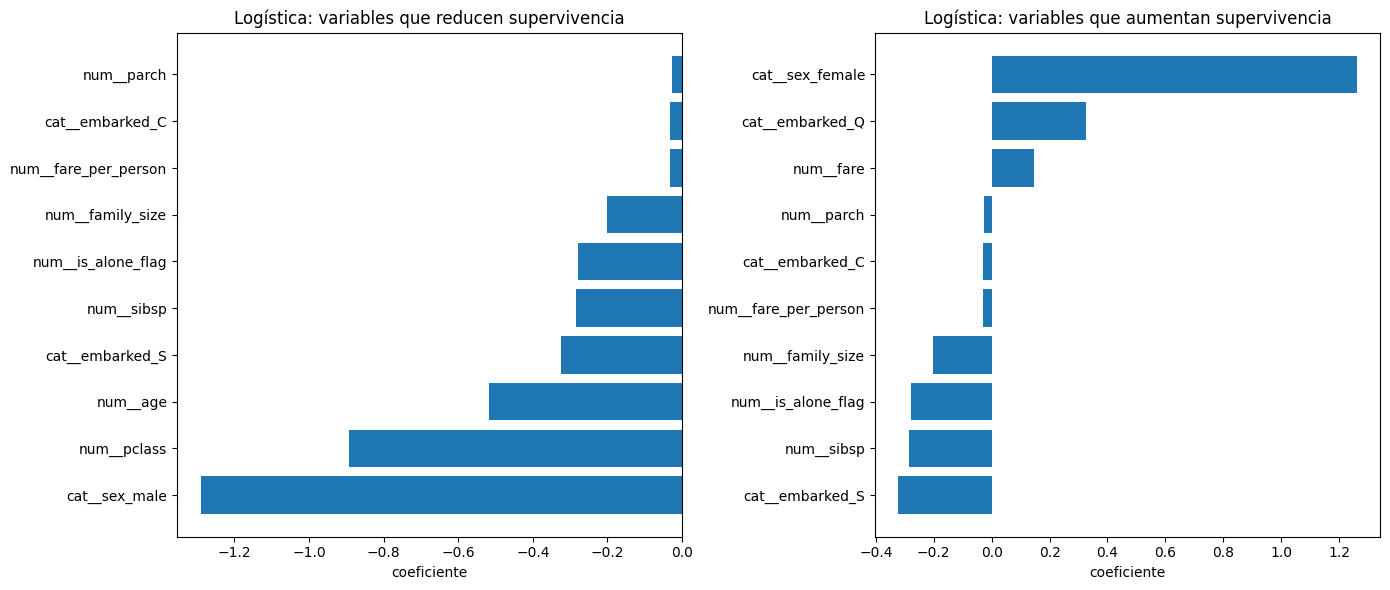

In [19]:

# Top efectos positivos y negativos
top_neg = coef_df.head(10).sort_values("coef")
top_pos = coef_df.tail(10).sort_values("coef")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_neg["feature"], top_neg["coef"])
axes[0].set_title("Logística: variables que reducen supervivencia")
axes[0].set_xlabel("coeficiente")

axes[1].barh(top_pos["feature"], top_pos["coef"])
axes[1].set_title("Logística: variables que aumentan supervivencia")
axes[1].set_xlabel("coeficiente")

plt.tight_layout()
plt.show()



## 7.1 Cómo explicar esto 

Ejemplos típicos:
- un coeficiente positivo para `sex_female` indica que ser mujer aumenta la probabilidad de supervivencia,
- un coeficiente negativo en ciertas categorías de clase o variables asociadas a vulnerabilidad reduce la probabilidad,
- el signo importa más que la magnitud bruta cuando las escalas son diferentes, aunque aquí escalamos las numéricas para facilitar lectura.

**Punto  clave:** la logística permite una narrativa causal-operativa más clara, aunque no necesariamente es el modelo más preciso.



# 8. Modelos black-box: importancia de variables

En modelos como Random Forest, XGBoost, LightGBM o CatBoost, ya no podemos “leer” la decisión con la misma facilidad que en una logística.

Por eso usamos herramientas de explicación.

La primera es la **Feature Importance** interna del modelo.


In [20]:

# =============================
# 10. Feature importance interna
# =============================
def get_model_feature_importance(pipe):
    model = pipe.named_steps["model"]
    feature_names = pipe.named_steps["prep"].get_feature_names_out()

    if hasattr(model, "feature_importances_"):
        imp = model.feature_importances_
        return pd.DataFrame({"feature": feature_names, "importance": imp}).sort_values("importance", ascending=False)
    else:
        return None

for candidate in ["RandomForest", "XGBoost", "LightGBM", "CatBoost"]:
    if candidate in fitted_models:
        fi_df = get_model_feature_importance(fitted_models[candidate])
        if fi_df is not None:
            print(f"\n=== {candidate} ===")
            display(fi_df.head(10))



=== RandomForest ===


,feature,importance
8,cat__sex_female,0.252732
9,cat__sex_male,0.219751
7,num__fare_per_person,0.126651
4,num__fare,0.118545
1,num__age,0.087428
0,num__pclass,0.081165
5,num__family_size,0.038670
2,num__sibsp,0.016426
3,num__parch,0.015771
6,num__is_alone_flag,0.015698



=== XGBoost ===


,feature,importance
8,cat__sex_female,0.377627
0,num__pclass,0.160361
9,cat__sex_male,0.118500
2,num__sibsp,0.046371
12,cat__embarked_S,0.042990
1,num__age,0.042772
7,num__fare_per_person,0.041637
5,num__family_size,0.038825
4,num__fare,0.033614
3,num__parch,0.028119



=== LightGBM ===


,feature,importance
1,num__age,2390
4,num__fare,2258
7,num__fare_per_person,1716
5,num__family_size,222
8,cat__sex_female,212
0,num__pclass,160
2,num__sibsp,158
12,cat__embarked_S,137
10,cat__embarked_C,127
9,cat__sex_male,77



=== CatBoost ===


,feature,importance
1,num__age,19.800073
4,num__fare,15.436677
7,num__fare_per_person,14.950093
9,cat__sex_male,13.869690
8,cat__sex_female,13.484380
0,num__pclass,8.630449
5,num__family_size,4.492867
2,num__sibsp,3.372317
12,cat__embarked_S,2.137548
10,cat__embarked_C,1.468846


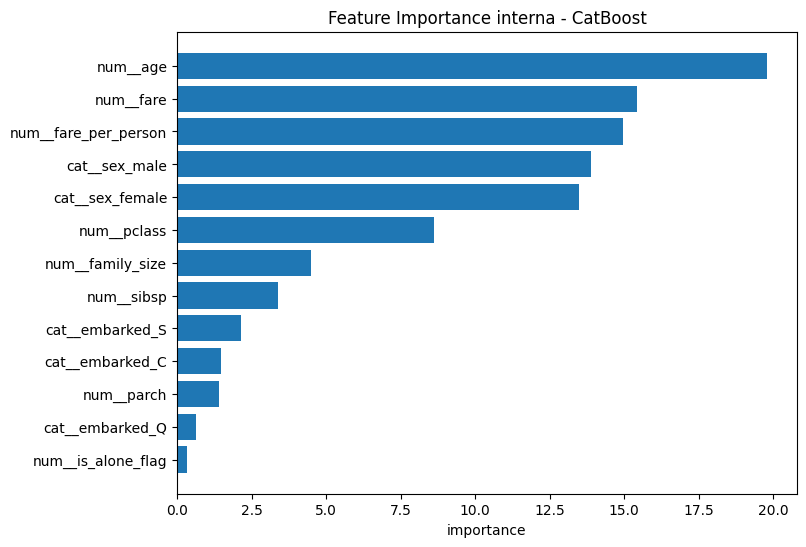

In [21]:

# Gráfico del mejor modelo si tiene feature_importances_
best_fi = get_model_feature_importance(best_pipe)
if best_fi is not None:
    top = best_fi.head(15).sort_values("importance")
    plt.figure(figsize=(8, 6))
    plt.barh(top["feature"], top["importance"])
    plt.title(f"Feature Importance interna - {best_model_name}")
    plt.xlabel("importance")
    plt.show()
else:
    print("El mejor modelo no expone feature_importances_.")



## 8.1 Advertencia metodológica

La **feature importance interna** es útil, pero no siempre es suficiente.

Problemas comunes:
- puede sesgarse por variables con muchas particiones,
- depende de la lógica interna del algoritmo,
- no siempre refleja impacto causal ni dirección,
- no te explica bien casos individuales. <--- IMPORTANTE

Por eso conviene complementar con métodos más robustos.



# 9. Permutation Importance

Este método responde a una pregunta muy útil:

> ¿Qué tanto empeora el modelo si destruimos la información de una variable?

La lógica es:
1. medimos el desempeño del modelo normal,
2. permutamos una variable,
3. volvemos a medir,
4. si el desempeño cae mucho, esa variable era importante.

**Ventaja:** es más agnóstico al modelo.


In [22]:

# =============================
# 11. Permutation Importance
# =============================
perm = permutation_importance(
    best_pipe,
    X_test,
    y_test,
    n_repeats=15,
    random_state=42,
    scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

perm_df.head(15)


,feature,importance_mean,importance_std
1,sex,0.220602,0.024420
2,age,0.048062,0.017152
0,pclass,0.036918,0.012380
9,fare_per_person,0.017020,0.012211
5,fare,0.012898,0.009175
7,family_size,0.007956,0.004756
6,embarked,0.007262,0.003847
3,sibsp,0.002674,0.004597
4,parch,-0.000280,0.001458
8,is_alone_flag,-0.002343,0.000871


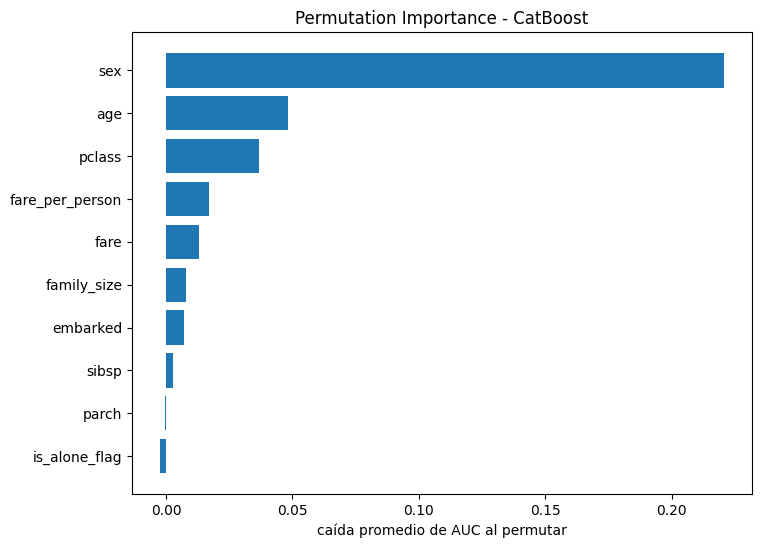

In [23]:

top_perm = perm_df.head(15).sort_values("importance_mean")
plt.figure(figsize=(8, 6))
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.title(f"Permutation Importance - {best_model_name}")
plt.xlabel("caída promedio de AUC al permutar")
plt.show()



## 9.1 Lectura 

Este gráfico suele ser muy bueno  porque es intuitivo:
- si al romper una variable el modelo empeora mucho, esa variable importa,
- si no cambia casi nada, la variable aporta poco.

Además, es excelente para comparar contra la importancia interna y discutir por qué no siempre coinciden.



# 10. Partial Dependence (PDP) e ICE

SHAP no es el único método.

## PDP
Muestra el efecto promedio de una variable sobre la predicción del modelo.

## ICE
Muestra trayectorias individuales, es decir, cómo cambia la predicción para observaciones concretas al variar una variable.

**Uso docente:** ayudan a responder:
- ¿la relación es lineal?
- ¿hay umbrales?
- ¿hay saturación?
- ¿hay heterogeneidad entre individuos?


In [24]:

# =============================
# 12. PDP / ICE
# =============================
candidate_features = []
for f in ["age", "fare", "family_size", "pclass"]:
    if f in X_test.columns:
        candidate_features.append(f)

candidate_features


['age', 'fare', 'family_size', 'pclass']

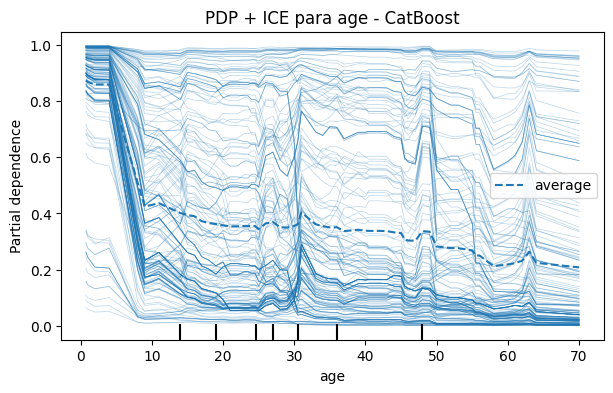

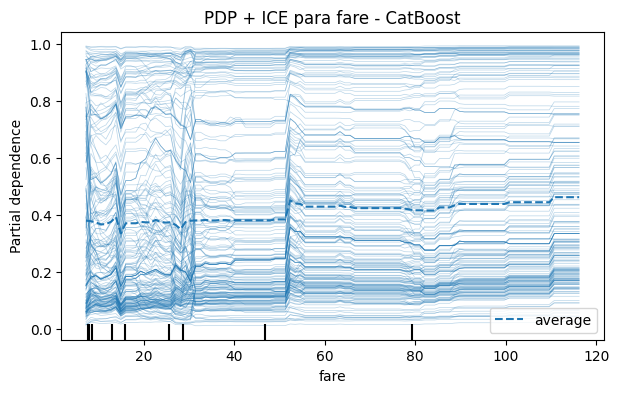

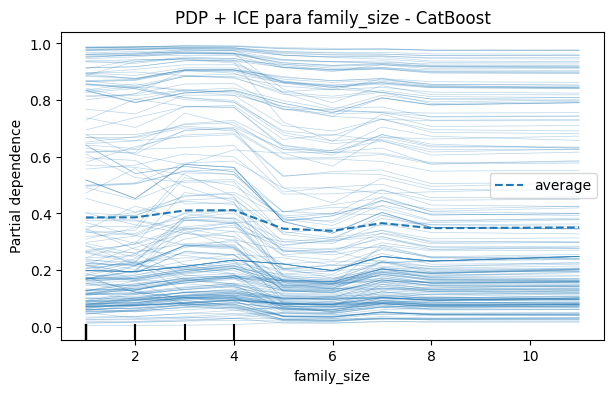

In [25]:

# Para pipelines, PartialDependenceDisplay puede trabajar directamente sobre X original.
for feat in candidate_features[:3]:
    fig, ax = plt.subplots(figsize=(7, 4))
    PartialDependenceDisplay.from_estimator(
        best_pipe,
        X_test,
        [feat],
        kind="both",   # both = PDP + ICE
        ax=ax
    )
    ax.set_title(f"PDP + ICE para {feat} - {best_model_name}")
    plt.show()



## 10.1 Cómo leer PDP / ICE

- La línea promedio (PDP) resume el efecto medio.
- Las líneas individuales (ICE) muestran si ese efecto es homogéneo o no.
- Si las curvas individuales divergen mucho, la relación depende del contexto de cada observación.

Esto permite introducir una idea muy poderosa:
> una variable puede ser importante, pero su efecto no necesariamente es lineal ni igual para todos.



# 11. Otras técnicas además de SHAP

En esta clase conviene mencionarlas explícitamente:

## A. Coeficientes / Odds Ratios
Ideales para modelos lineales o scorecards.

## B. Feature Importance
Útil, rápida, pero limitada.

## C. Permutation Importance
Más agnóstica y comparativa.

## D. PDP / ICE
Muy buenas para relaciones no lineales y umbrales.

## E. LIME
Explica observaciones individuales perturbando alrededor del punto.

# LIME: explicación local de predicciones

LIME significa **Local Interpretable Model-agnostic Explanations**.

La idea principal es aproximar localmente el comportamiento de un modelo complejo mediante un modelo simple e interpretable.

En lugar de explicar todo el modelo, LIME responde:

> ¿Qué variables fueron más importantes para esta predicción específica?

## Idea intuitiva

Aunque el modelo global sea complejo, cerca de una observación puntual puede aproximarse con una regla local simple.

## Ventajas
- Es intuitivo
- Funciona con muchos tipos de modelos
- Es útil para explicaciones individuales

## Limitaciones
- Es una aproximación local
- Puede variar entre ejecuciones
- No siempre es tan estable como SHAP

## F. Surrogate Models
Entrenas un modelo simple para aproximar a uno complejo y ganar interpretación.

## G. Rule Extraction
Extraes reglas de decisión comprensibles desde modelos complejos o árboles.

### Idea clave
SHAP es muy poderoso, pero **no es la única herramienta**.  
Un Data Scientist serio no se casa con una sola técnica: triangula evidencia.


# H. Comparación entre SHAP y LIME

Tanto SHAP como LIME son métodos de explicabilidad local, pero difieren en su enfoque.

## SHAP
- Tiene base teórica en valores de Shapley
- Proporciona explicaciones locales y globales
- Suele ser más consistente
- Es muy fuerte en modelos basados en árboles

## LIME
- Aproxima localmente el modelo con uno simple
- Es intuitivo y fácil de explicar
- Es útil para analizar observaciones individuales
- Puede ser menos estable que SHAP

## Idea clave

SHAP y LIME no compiten necesariamente; pueden verse como herramientas complementarias para entender modelos complejos.

# 12. SHAP: teoría breve

SHAP proviene de los **valores de Shapley** de la teoría de juegos cooperativos.

La idea es repartir la predicción de un modelo entre las variables según su contribución.

---

## Descomposición de la predicción

La predicción del modelo puede escribirse como:

$$
f(x) = \phi_0 + \sum_{j=1}^{p} \phi_j
$$

donde:

- $f(x)$ es la predicción del modelo para la observación $x$
- $\phi_0$ es el **valor base** del modelo (predicción promedio)
- $\phi_j$ es la **contribución de la variable $j$**
- $p$ es el número total de variables

---

## Interpretación

La predicción final se obtiene sumando:

$$
\text{Predicción} = \text{Valor base} + \sum \text{contribuciones de variables}
$$

Cada valor $\phi_j$ puede:

- **aumentar** la predicción (si $\phi_j > 0$)
- **reducir** la predicción (si $\phi_j < 0$)

---

## Ventajas de SHAP

- Proporciona **explicaciones locales y globales**
- Tiene una **base teórica sólida** (teoría de juegos)
- Permite ver **magnitud y dirección del efecto**
- Funciona especialmente bien en **modelos basados en árboles**
  - Random Forest
  - XGBoost
  - LightGBM
  - CatBoost

---

## Desventajas de SHAP

- Puede ser **computacionalmente costoso**
- Requiere cuidado cuando hay **alta correlación entre variables**
- Las interpretaciones pueden volverse complejas en datasets muy grandes

In [26]:

# =============================
# 13. Preparación de matrices transformadas para SHAP
# =============================
X_train_trans = best_pipe.named_steps["prep"].transform(X_train)
X_test_trans = best_pipe.named_steps["prep"].transform(X_test)
best_estimator = best_pipe.named_steps["model"]
best_feature_names = best_pipe.named_steps["prep"].get_feature_names_out()

# Algunas librerías devuelven sparse matrix. Convertimos a denso solo si hace falta.
if hasattr(X_train_trans, "toarray"):
    X_train_shap = X_train_trans.toarray()
else:
    X_train_shap = X_train_trans

if hasattr(X_test_trans, "toarray"):
    X_test_shap = X_test_trans.toarray()
else:
    X_test_shap = X_test_trans

X_train_shap_df = pd.DataFrame(X_train_shap, columns=best_feature_names)
X_test_shap_df = pd.DataFrame(X_test_shap, columns=best_feature_names)

X_train_shap_df.head()


,num__pclass,num__age,num__sibsp,num__parch,num__fare,num__family_size,num__is_alone_flag,num__fare_per_person,cat__sex_female,cat__sex_male,cat__embarked_C,cat__embarked_Q,cat__embarked_S
0,-1.579334,0.405333,0.536677,-0.451483,1.240397,0.105501,-1.280748,0.635224,1.0,0.0,0.0,0.0,1.0
1,-0.376375,-0.829764,-0.464720,-0.451483,-0.436028,-0.553139,0.780794,-0.259828,0.0,1.0,0.0,0.0,1.0
2,-0.376375,0.328140,-0.464720,-0.451483,-0.383310,-0.553139,0.780794,-0.194969,0.0,1.0,0.0,0.0,1.0
3,0.826584,-1.987668,-0.464720,1.951631,-0.192999,0.764140,-1.280748,-0.341766,1.0,0.0,0.0,0.0,1.0
4,-0.376375,-0.675377,-0.464720,-0.451483,-0.436028,-0.553139,0.780794,-0.259828,1.0,0.0,0.0,0.0,1.0


In [27]:

# =============================
# 14. SHAP explainer
# =============================
if HAS_SHAP:
    try:
        explainer = shap.Explainer(best_estimator, X_train_shap_df)
        shap_values = explainer(X_test_shap_df)
        print("Explainer construido correctamente para:", best_model_name)
    except Exception as e:
        print("No se pudo construir shap.Explainer genérico:", e)
        shap_values = None
else:
    shap_values = None
    print("SHAP no disponible en este entorno.")


Explainer construido correctamente para: CatBoost



# 13. SHAP global

La vista global responde preguntas como:
- ¿qué variables dominan el modelo?
- ¿qué dirección tienen?
- ¿cuánta dispersión muestran?
- ¿hay variables con efecto muy no lineal?

En un **summary plot**:
- el eje X muestra el impacto SHAP,
- el color representa valores altos/bajos de la variable,
- cada punto es una observación.


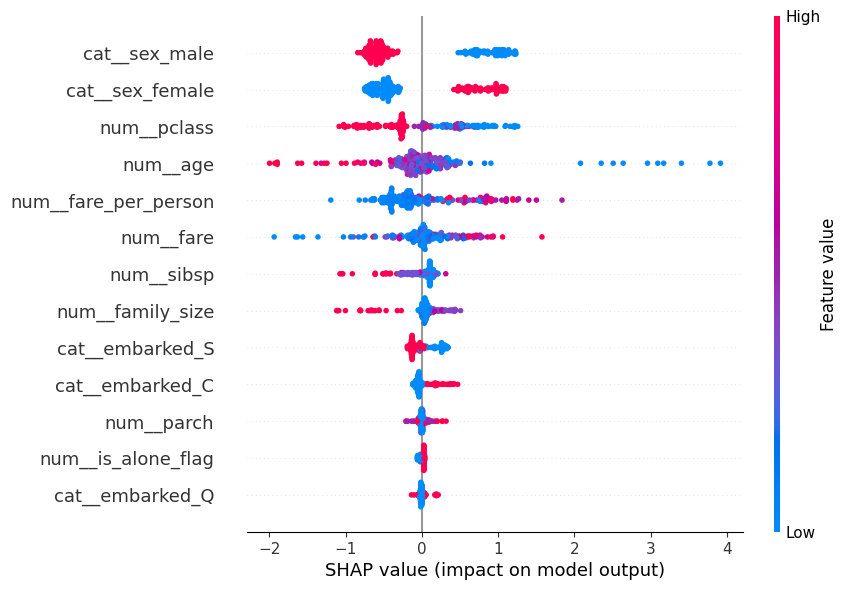

In [28]:

# =============================
# 15. SHAP summary plot
# =============================
if shap_values is not None:
    shap.plots.beeswarm(shap_values, max_display=15)
else:
    print("No hay shap_values disponibles.")


# Cómo leer el gráfico

##  Eje vertical (Variables)

El eje vertical muestra las **variables ordenadas por importancia global**.

Las variables en la parte superior son las que **más influyen en las predicciones del modelo**.

En este caso destacan:

- `sex`
- `pclass`
- `age`
- `fare_per_person`
- `fare`

Esto indica que el modelo considera estas variables como las **más relevantes para predecir la supervivencia**.

---

##  Eje horizontal (SHAP value)

El eje horizontal muestra el **valor SHAP**, que representa el impacto de la variable en la predicción.

- Valores **positivos** ($SHAP > 0$)  
  → aumentan la probabilidad de sobrevivir.

- Valores **negativos** ($SHAP < 0$)  
  → reducen la probabilidad de sobrevivir.

La línea vertical en **0** representa el **valor base del modelo**.

---

## Puntos del gráfico

Cada punto representa **una observación individual del dataset**.

La posición horizontal indica cuánto contribuyó esa variable a la predicción de ese pasajero.

Una dispersión amplia indica que la variable tiene **impactos muy distintos dependiendo del caso**.

---

## Colores de los puntos

El color indica el **valor de la variable**.

- 🔴 Rojo → valor alto de la variable  
- 🔵 Azul → valor bajo de la variable

Esto permite observar **cómo cambia el efecto según el valor de la variable**.

---

# Interpretación de variables importantes

## Sexo (`sex`)

Los valores asociados a **ser mujer** tienden a mover la predicción hacia la derecha.

Esto significa que **ser mujer aumenta la probabilidad de sobrevivir**.

Por el contrario, **ser hombre tiende a reducir la probabilidad de supervivencia**.

Esto coincide con el contexto histórico del Titanic, donde se priorizó la evacuación de mujeres y niños.

---

## Clase del pasajero (`pclass`)

Se observa que los pasajeros de **clase alta (1ª clase)** tienen contribuciones positivas.

Mientras que los pasajeros de **clases más bajas** tienden a tener contribuciones negativas.

Esto sugiere que el **estatus socioeconómico influyó en las probabilidades de supervivencia**.

---

## Edad (`age`)

La edad muestra un efecto heterogéneo.

En general:

- edades más bajas tienden a aumentar la probabilidad de supervivencia
- edades mayores tienden a reducirla

Esto puede reflejar el principio de evacuación de **"women and children first"**.

---

## Tarifa del ticket (`fare`)

Los valores altos de tarifa aparecen asociados con contribuciones positivas.

Esto sugiere que **pagar un ticket más caro (relacionado con clases más altas)** aumenta la probabilidad de sobrevivir.

---

# Conclusión

El gráfico SHAP permite observar simultáneamente:

- **qué variables son importantes**
- **cómo influyen en la predicción**
- **cómo varía ese efecto entre observaciones**

A diferencia de la importancia de variables tradicional, SHAP permite entender **tanto la magnitud como la dirección del efecto de cada variable en el modelo**.


## 13.1 Cómo interpretar el beeswarm

Ejemplo de lectura:
- puntos a la derecha empujan hacia mayor probabilidad de sobrevivir,
- puntos a la izquierda empujan hacia menor probabilidad,
- si una variable tiene gran dispersión horizontal, su impacto cambia mucho entre casos,
- el color ayuda a entender si valores altos o bajos de la variable impulsan el resultado.

Este gráfico suele ser el punto más “wow” de la clase.



# 14. SHAP individual

La explicación local responde:

> ¿Por qué este pasajero en particular fue clasificado como sobreviviente o no sobreviviente?

Esto es crucial en negocio real:
- rechazo de crédito,
- sospecha de fraude,
- recomendación médica,
- priorización de clientes.


In [29]:

# =============================
# 16. Selección de observación individual
# =============================
row_idx = 0
print("Índice local en test:", row_idx)
display(X_test.iloc[[row_idx]])
print("Target real:", int(y_test.iloc[row_idx]))
print("Probabilidad predicha:", round(best_pipe.predict_proba(X_test.iloc[[row_idx]])[:, 1][0], 4))


Índice local en test: 0


,pclass,sex,age,sibsp,parch,fare,embarked,family_size,is_alone_flag,fare_per_person
157,3,male,30.0,0,0,8.05,S,1,1,8.05


Target real: 0
Probabilidad predicha: 0.0901


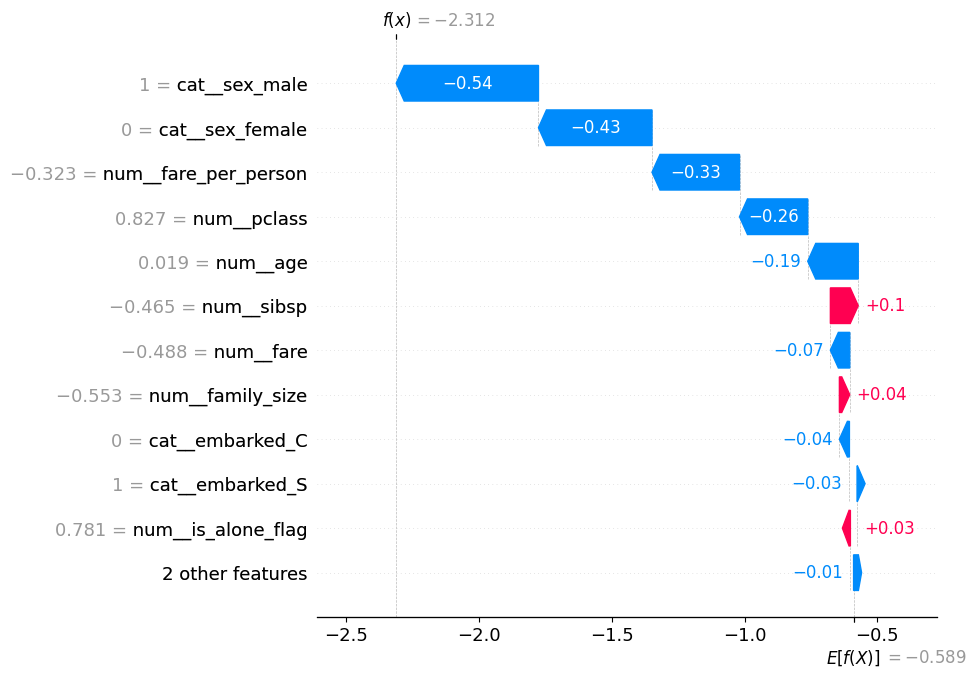

In [30]:

# Waterfall plot local
if shap_values is not None:
    shap.plots.waterfall(shap_values[row_idx], max_display=12)
else:
    print("No hay shap_values disponibles.")


# Cómo leer el gráfico

El gráfico muestra cómo se pasa desde el **valor base del modelo** hasta la **predicción final**.

Cada barra representa **la contribución de una variable**.

### Colores

- 🔵 Azul → la variable **reduce la predicción**
- 🔴 Rojo → la variable **aumenta la predicción**

---

# Variables que más reducen la predicción

Las variables que más empujan la predicción hacia valores negativos son:

### `sex_male`

Contribución:

$$
-0.54
$$

Interpretación:

Ser **hombre** reduce significativamente la probabilidad de sobrevivir.

Esto coincide con el patrón histórico del Titanic.

---

### `sex_female`

Contribución:

$$
-0.43
$$

El hecho de **no ser mujer** también reduce la probabilidad de supervivencia.

---

### `fare_per_person`

Contribución:

$$
-0.33
$$

Una **tarifa relativamente baja por persona** reduce la probabilidad de sobrevivir, lo que puede reflejar menor estatus socioeconómico.

---

### `pclass`

Contribución:

$$
-0.26
$$

Clases más bajas tienden a **disminuir la probabilidad de sobrevivir**.

---

### `age`

Contribución:

$$
-0.19
$$

La edad también influye negativamente en esta observación específica.

---

# Variables que aumentan ligeramente la predicción

Algunas variables empujan la predicción hacia arriba:

### `sibsp`

Contribución:

$$
+0.10
$$

Tener familiares a bordo puede haber aumentado ligeramente la probabilidad de supervivencia.

---

### `family_size`

Contribución:

$$
+0.04
$$

El tamaño de la familia también aporta ligeramente de forma positiva.

---

### `is_alone_flag`

Contribución:

$$
+0.03
$$

Viajar solo o acompañado puede modificar ligeramente la predicción.

---

# Interpretación final

El modelo parte de una **predicción promedio**:

$$
E[f(X)] = -0.589
$$

Luego las variables empujan la predicción principalmente hacia abajo debido a:

- ser hombre
- no ser mujer
- pagar tarifa baja
- viajar en clase más baja
- edad

Finalmente se obtiene:

$$
f(x) = -2.312
$$

lo que corresponde a **una probabilidad muy baja de sobrevivir** para esta observación.

---

# Idea clave

El SHAP Waterfall Plot permite:

- explicar **una predicción individual**
- identificar **qué variables influyeron más**
- ver **dirección y magnitud del efecto**

Esto es especialmente útil en aplicaciones donde se necesita justificar decisiones del modelo, como:

- riesgo crediticio
- diagnóstico médico
- detección de fraude
- sistemas de recomendación


## 14.1 Cómo leer el waterfall

- Partimos de un valor base.
- Cada variable empuja la predicción hacia arriba o hacia abajo.
- El valor final explica la probabilidad del caso observado.

Esto permite contar historias de negocio muy concretas:

> “Este pasajero tuvo alta probabilidad de sobrevivir porque era mujer, viajaba en cierta clase y tenía determinados atributos; sin embargo, otros factores restaron algo de probabilidad”.



# 15. Comparación metodológica final

## Logistic Regression
**Fortaleza:** interpretación directa  
**Debilidad:** puede perder capacidad predictiva ante relaciones complejas

## Random Forest
**Fortaleza:** robusto y flexible  
**Debilidad:** menos transparente

## XGBoost / LightGBM / CatBoost
**Fortaleza:** alto desempeño tabular  
**Debilidad:** más complejos de explicar sin herramientas extra

## Métodos de explicación revisados
- coeficientes / odds ratios,
- feature importance,
- permutation importance,
- PDP / ICE,
- SHAP global,
- SHAP individual.

### Mensaje central
En ML moderno, **precisión sin comprensión** puede ser riesgosa.  
Y **comprensión sin validación** también puede ser insuficiente.
Lo correcto es equilibrar:
- desempeño,
- robustez,
- trazabilidad,
- interpretabilidad.



# 16. Cierre 

## Cuándo priorizar interpretabilidad
- scorecards,
- crédito regulado,
- decisiones públicas,
- modelos de negocio con obligación de justificación.

## Cuándo aceptar modelos más complejos
- cuando la mejora predictiva es relevante,
- cuando el costo del error es alto,
- cuando existen herramientas de gobernanza y explicabilidad,
- cuando el negocio tolera mayor complejidad operativa.

## Regla práctica para tus alumnos
1. empieza con un baseline interpretable,  
2. compara contra modelos más potentes,  
3. mide la mejora real,  
4. aplica explicabilidad,  
5. decide con criterio de negocio.



# 17. Ejercicios propuestos para alumnos

1. Comparar la logística contra Random Forest y explicar cuál elegirían para una entidad financiera.  
2. Revisar si la variable `sex` domina demasiado el modelo y discutir sesgo / fairness.  
3. Cambiar hiperparámetros de XGBoost o LightGBM y comparar:
   - AUC
   - permutation importance
   - SHAP global  
4. Tomar 3 pasajeros del test y redactar una explicación de negocio de cada predicción.  
5. Construir un mini informe ejecutivo:
   - mejor modelo,
   - variables más relevantes,
   - método de explicación más útil,
   - riesgos del modelo.



# 18. Finalmente

> Un modelo interpretable se entiende por diseño.  
> Un modelo explicable necesita herramientas para ser comprendido.  
> En ciencia de datos aplicada, no basta con predecir bien: también hay que poder defender la decisión.
